# Clasificación de Películas con NLP

Dataset: movie_metadata.csv

Modelos:
- TF-IDF + Naive Bayes
- LSTM

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

## Carga del dataset

In [2]:
df = pd.read_csv("movie_metadata.csv")
df.head()

,Id,movie_title,genero,plot_keywords,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,...,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes
0,1,Avatar,Action|Adventure|Fantasy|Sci-Fi,avatar|future|marine|native|paraplegic,Color,James Cameron,723.0,178.0,0.0,855.0,...,3054.0,English,USA,PG-13,237000000.0,2009.0,936.0,7.9,1.78,33000
1,2,Pirates of the Caribbean: At World's End,Action|Adventure|Fantasy,goddess|marriage ceremony|marriage proposal|pi...,Color,Gore Verbinski,302.0,169.0,563.0,1000.0,...,1238.0,English,USA,PG-13,300000000.0,2007.0,5000.0,7.1,2.35,0
2,3,Spectre,Action|Adventure|Thriller,bomb|espionage|sequel|spy|terrorist,Color,Sam Mendes,602.0,148.0,0.0,161.0,...,994.0,English,UK,PG-13,245000000.0,2015.0,393.0,6.8,2.35,85000
3,4,The Dark Knight Rises,Action|Thriller,deception|imprisonment|lawlessness|police offi...,Color,Christopher Nolan,813.0,164.0,22000.0,23000.0,...,2701.0,English,USA,PG-13,250000000.0,2012.0,23000.0,8.5,2.35,164000
4,5,Star Wars: Episode VII - The Force Awakens ...,Documentary,NaN,NaN,Doug Walker,NaN,NaN,131.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,12.0,7.1,NaN,0


## Selección de variables

In [4]:
df = df[['plot_keywords', 'genero']].dropna()
df.head()

,plot_keywords,genero
0,avatar|future|marine|native|paraplegic,Action|Adventure|Fantasy|Sci-Fi
1,goddess|marriage ceremony|marriage proposal|pi...,Action|Adventure|Fantasy
2,bomb|espionage|sequel|spy|terrorist,Action|Adventure|Thriller
3,deception|imprisonment|lawlessness|police offi...,Action|Thriller
5,alien|american civil war|male nipple|mars|prin...,Action|Adventure|Sci-Fi


## Preprocesamiento

In [5]:
def limpiar_texto(texto):
    texto = texto.lower()
    texto = texto.replace('|', ' ')
    texto = re.sub(r'[^a-z ]', '', texto)
    return texto

df['texto'] = df['plot_keywords'].apply(limpiar_texto)

##  Definición del target

In [7]:
df['categoria'] = df['genero'].apply(lambda x: x.split('|')[0])

## Distribución de clases

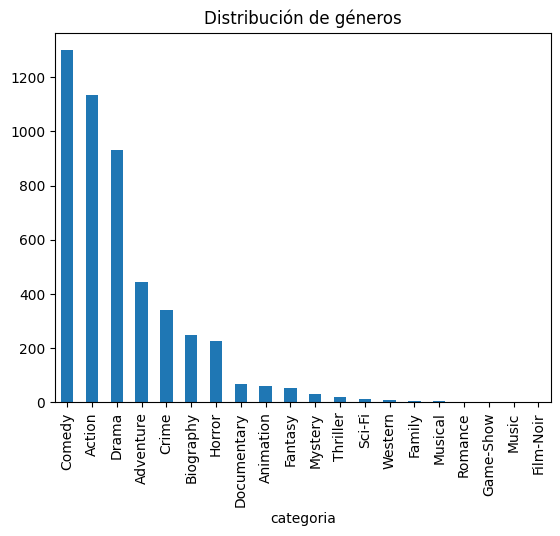

In [8]:
df['categoria'].value_counts().plot(kind='bar')
plt.title("Distribución de géneros")
plt.show()

## División de datos

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df['texto'],
    df['categoria'],
    test_size=0.2,
    random_state=42
)

## TF-IDF

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=3000)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

## Naive Bayes

In [11]:
from sklearn.naive_bayes import MultinomialNB

modelo_nb = MultinomialNB()
modelo_nb.fit(X_train_tfidf, y_train)

y_pred_nb = modelo_nb.predict(X_test_tfidf)

## Evaluación

In [12]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred_nb))

              precision    recall  f1-score   support

      Action       0.48      0.77      0.60       230
   Adventure       0.80      0.08      0.15       100
   Animation       0.00      0.00      0.00        11
   Biography       0.00      0.00      0.00        59
      Comedy       0.42      0.76      0.54       253
       Crime       0.00      0.00      0.00        67
 Documentary       0.00      0.00      0.00        14
       Drama       0.36      0.29      0.32       171
      Family       0.00      0.00      0.00         2
     Fantasy       0.00      0.00      0.00        12
      Horror       0.50      0.02      0.05        42
     Musical       0.00      0.00      0.00         2
     Mystery       0.00      0.00      0.00         8
      Sci-Fi       0.00      0.00      0.00         3
    Thriller       0.00      0.00      0.00         1
     Western       0.00      0.00      0.00         3

    accuracy                           0.44       978
   macro avg       0.16   

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


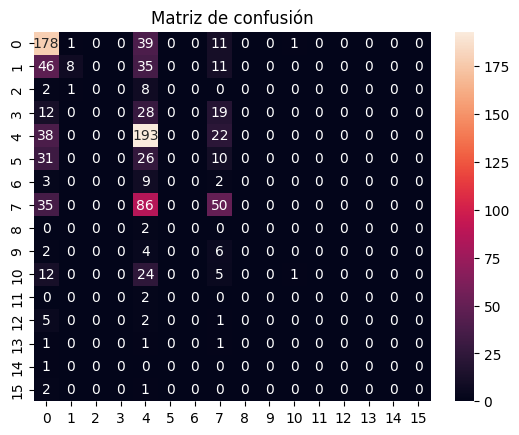

In [13]:
cm = confusion_matrix(y_test, y_pred_nb)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Matriz de confusión")
plt.show()

## Modelo LSTM

In [14]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=50)
X_test_pad = pad_sequences(X_test_seq, maxlen=50)

In [15]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

modelo_lstm = Sequential([
    Embedding(5000, 64),
    LSTM(32),
    Dense(16, activation='relu'),
    Dense(len(le.classes_), activation='softmax')
])

modelo_lstm.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [17]:
history = modelo_lstm.fit(
    X_train_pad,
    y_train_enc,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/5
98/98 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.2237 - loss: 2.2944 - val_accuracy: 0.2529 - val_loss: 1.9449
Epoch 2/5
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.3391 - loss: 1.9482 - val_accuracy: 0.3870 - val_loss: 1.8589
Epoch 3/5
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.4644 - loss: 1.7030 - val_accuracy: 0.3934 - val_loss: 1.8108
Epoch 4/5
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.5423 - loss: 1.4645 - val_accuracy: 0.4049 - val_loss: 1.8430
Epoch 5/5
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.6341 - loss: 1.2067 - val_accuracy: 0.4100 - val_loss: 1.9828


In [18]:
loss, acc = modelo_lstm.evaluate(X_test_pad, y_test_enc)
print("Accuracy:", acc)

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3926 - loss: 2.0175
Accuracy: 0.39263802766799927


##  Overfitting

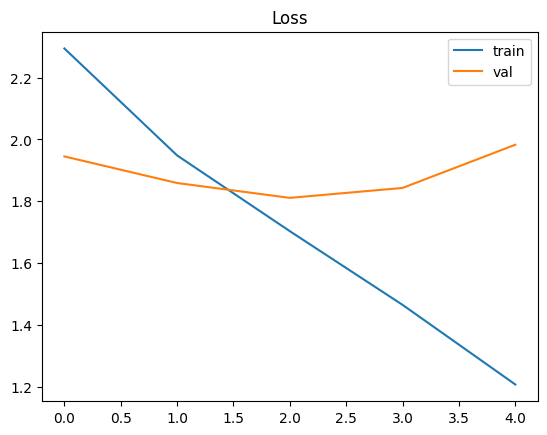

In [19]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.legend()
plt.title("Loss")
plt.show()

##  Conclusión

- Naive Bayes funciona muy bien con pocos datos
- LSTM no mejora mucho por falta de contexto
- El dataset limita el rendimiento

El dato es más importante que el modelo


In [20]:
!pip install transformers datasets torch

In [21]:
from datasets import Dataset

df_hf = df[['texto', 'categoria']].copy()

dataset = Dataset.from_pandas(df_hf)
dataset = dataset.train_test_split(test_size=0.2)

In [22]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [23]:
def tokenize(example):
    return tokenizer(
        example['texto'],
        truncation=True,
        padding='max_length',
        max_length=64
    )

dataset = dataset.map(tokenize)

Map:   0%|          | 0/3912 [00:00<?, ? examples/s]

Map:   0%|          | 0/978 [00:00<?, ? examples/s]

In [24]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['categoria_enc'] = le.fit_transform(df['categoria'])

label_map = {label: i for i, label in enumerate(le.classes_)}

In [25]:
def encode_labels(example):
    example['label'] = label_map[example['categoria']]
    return example

dataset = dataset.map(encode_labels)

Map:   0%|          | 0/3912 [00:00<?, ? examples/s]

Map:   0%|          | 0/978 [00:00<?, ? examples/s]

In [26]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=len(le.classes_)
)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [29]:
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=2,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    logging_dir="./logs"
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [30]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset['train'],
    eval_dataset=dataset['test']
)

trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss
500,1.784402


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=978, training_loss=1.553844366093111, metrics={'train_runtime': 4961.0657, 'train_samples_per_second': 1.577, 'train_steps_per_second': 0.197, 'total_flos': 257364199268352.0, 'train_loss': 1.553844366093111, 'epoch': 2.0})

In [31]:
import torch

def predecir_genero(texto):
    inputs = tokenizer(
        texto,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=64
    )

    outputs = model(**inputs)

    probs = torch.nn.functional.softmax(outputs.logits, dim=1)
    pred = torch.argmax(probs, dim=1).item()

    return le.inverse_transform([pred])[0]

In [34]:
texto = "school teenager friendshi"

print("Predicción:", predecir_genero(texto))

Predicción: Drama


In [35]:
ejemplos = [
    "war soldier battle army",
    "love relationship kiss romance",
    "police murder investigation crime",
    "space alien future robot",
    "school teenager friendship drama"
]

for t in ejemplos:
    print(t, "→", predecir_genero(t))

war soldier battle army → Action
love relationship kiss romance → Comedy
police murder investigation crime → Crime
space alien future robot → Action
school teenager friendship drama → Comedy
